In [238]:
import numpy

#object-oriented Monte Carlo

keWeird = 9.144e-46 #the coulombic constant in kcal angstrom /mol e^{2}
qDict = {'O':0.0, 'H':0.52, 'M': -1.04, 'Cl':-1.0, 'C':0.40, 'methyl': 0.20}
sigDict = {'O':3.15358, 'H':0.0, 'M': 0.0, 'Cl':4.417, 'C':2.250, 'methyl': 3.000}
epsDict = {'O':0.15504, 'H':0.0, 'M': 0.0, 'Cl':0.118, 'C':0.050, 'methyl': 0.100}
rL = 7.5
rU = 8.0
boltzmann = 1.987e-3 #kcal/(mol K)

radianDisplace = 0.2
posDisplace = 0.3

def rotateY(theta):
    return numpy.array([[numpy.cos(theta), 0, numpy.sin(theta)], [0, 1, 0], [-numpy.sin(theta), 0, numpy.cos(theta)]])

def rotateZ(theta):
    return numpy.array([[numpy.cos(theta), numpy.sin(theta), 0], [-numpy.sin(theta), numpy.cos(theta), 0], [0, 0, 1]])

def changeOfBasisWater(mol):
    h1 = mol.interactionSites[1].relPos
    h2 = mol.interactionSites[2].relPos
    row1 = h2 - h1
    row1 = row1/1.5139
    row2 = numpy.cross(h2, h1)
    row2 = row2/0.886963732
    row3 = -(h1 + h2)
    row3 = row3/1.17176
    return numpy.array([row1, row2, row3])

def changeOfBasisButyl(mol):
    h1 = mol.interactionSites[1].relPos
    h2 = mol.interactionSites[2].relPos
    row1 = h2 - h1
    row1 = row1/2.554774
    row2 = numpy.cross(h2, h1)
    row2 = row2/1.884145825
    row3 = -(h1 + h2)
    row3 = row3/1.475
    return numpy.array([row1, row2, row3])

changeOfBasis = {'water': changeOfBasisWater, 'tbutyl': changeOfBasisButyl}


class interactSite:
    
    def __init__(self, element, relativePositionVector, molecule = None):
       self.molecule = molecule
       self.element = element
       self.relPos = relativePositionVector 
       self.q = qDict[element]
       self.sig = sigDict[element]
       self.eps = epsDict[element]
       
    def copy(self):
        return interactSite(self.element, self.relPos)

class molecule:
    
    def __init__(self, type, position, interactionSites):
        self.type = type
        self.pos = position   #position for the central atom
        self.interactionSites = interactionSites
        for iSite in interactionSites:
            iSite.molecule = self
        
    def rotateMolY(self):   #theta in radians
        theta = numpy.random.uniform(-radianDisplace, radianDisplace)
        S = changeOfBasis[self.type](self)
        matrix = numpy.matmul(S, numpy.matmul(rotateY(theta),numpy.linalg.inv(S)))
        for iSite in self.interactionSites:
            iSite.relPos = matrix.dot(iSite.relPos)
    
    def rotateMolZ(self):
        theta = numpy.random.uniform(-radianDisplace, radianDisplace)
        S = changeOfBasis[self.type](self)
        matrix = numpy.matmul(S, numpy.matmul(rotateZ(theta),numpy.linalg.inv(S)))
        for iSite in self.interactionSites:
            iSite.relPos = matrix.dot(iSite.relPos)
            
    def copy(self):
        newInterSites = []
        for iSite in self.interactionSites:
            newInterSites.append(iSite.copy())
        return molecule(self.type, self.pos, newInterSites)
        
    
    def graph(self, plotter):
        positions = [self.pos]
        for iSite in self.interactionSites:
            positions.append(self.pos + iSite.relPos)
        posArray = numpy.array(positions)
        plotter.scatter(posArray[:, 0], posArray[:,1], posArray[:, 2])
 
class MC:
    
    def __init__(self, conc, boxlength, temp):
        self.boxlength = boxlength
        self.temp = temp
        particlesPerDim, moleculePositionArray = self.initializeCoordinates(conc, boxlength)
        self.N = particlesPerDim**3
        print(particlesPerDim)
        center = int(numpy.ceil(particlesPerDim/2))
        cat = particlesPerDim*particlesPerDim*(center-1) + particlesPerDim*(center-1) + center -1
        self.cat = cat
        an = cat + particlesPerDim * particlesPerDim
        self.an = an
        molecules = []
        for i in range(len(moleculePositionArray)):
            if i == cat:    
                molecules.append(createTButyl(moleculePositionArray[i]))
            elif i == an:    
                molecules.append(createChloride(moleculePositionArray[i]))
            else:
                molecules.append(createWater(moleculePositionArray[i]))
        print("initial ionic distance")
        print(moleculePositionArray[cat] - moleculePositionArray[an])
        self.molecules = molecules
            
               
    def combineParameter(self, param1, param2):
        return numpy.sqrt(param1*param2)

    def potentialEquation(self, iSite1, iSite2): 
        pos1 = iSite1.relPos + iSite1.molecule.pos 
        pos2 = iSite2.relPos + iSite2.molecule.pos
        r = self.closestCopyDistance(self.boxlength, pos1, pos2, rU)
        if r == None:
            return 0
        coulombicTerm = keWeird * iSite1.q * iSite2.q/r
        epsilon = self.combineParameter(iSite1.eps, iSite2.eps)
        sigma = self.combineParameter(iSite1.sig, iSite2.sig)
        sigOverRSix = (sigma/r)**6
        ULJ = 4 * epsilon * (sigOverRSix*sigOverRSix - sigOverRSix)
        potential = coulombicTerm + ULJ
        if (iSite1.element == 'O' and iSite2.element != 'O') or (iSite1.element != 'O' and iSite2.element == 'O'):
            potential = potential * numpy.sqrt(self.potentialScale(r*r))
        return potential
    
    def energySet(self):
        energySum = 0
        for i in range(self.N):
            particle1 = self.molecules[i]
            for j in range(i+1, self.N):
                particle2 = self.molecules[j]
                for iSite1 in particle1.interactionSites:
                    for iSite2 in particle2.interactionSites:
                        energySum += self.potentialEquation(iSite1, iSite2)
        return energySum
    
    def energyParticle(self, particle):
        energySum = 0
        for j in range(len(self.molecules)):
            particlePair = self.molecules[j]
            if particle == particlePair:
                continue
            for iSite1 in particle.interactionSites:
                for iSite2 in particlePair.interactionSites:
                    energySum += self.potentialEquation(iSite1, iSite2)
        return energySum
       

    def potentialScale(self, distanceSq):
        if distanceSq<= rL*rL:
            return 1
        if distanceSq < rU*rU:
            return (rU*rU - distanceSq)/(rU*rU - rL*rL)
        return 0
    
    def metropolis(self, Eold, Enew):
        T = self.temp
        if Enew == numpy.inf:
            return False
        deltaU = Enew-Eold
        chi = numpy.exp(-deltaU/(boltzmann* T))
        prob = numpy.min([1.0, chi])
        random = numpy.random.uniform()
        return random < prob
    
    def MC_step(self, particleIndex):
        particle = self.molecules[particleIndex]
        particleHolder = particle.copy()
        eOldParticle = self.energyParticle(particle)
        self.translate(particle)
        if particle.type != 'Cl':
            particle.rotateMolY()
            particle.rotateMolZ()
        eNewParticle = self.energyParticle(particle)
        acceptance = self.metropolis(eOldParticle, eNewParticle)
        if not acceptance:
            self.molecules[particleIndex] = particleHolder
            return False, 0.0
        if acceptance:
            return True, eNewParticle - eOldParticle

    def MC_walk(self, S):
        energyTracker = numpy.zeros(S)
        acceptanceTracker = numpy.zeros(S)
        ionicTracker = numpy.zeros(S)
        energy = self.energySet()
        energyFile = open("MC_walk_energies_12", 'w')
        acceptanceFile = open("MC_walk_acceptances_12", 'w')
        ionFile = open("MC_walk_ionic_distanace_12", 'w')
        for s in range(S):
            print("s: " + str(s))
            acceptances = 0
            accept, energyChange = self.MC_step(self.cat)
            if accept:
                acceptances += 1
            energy += energyChange
            accept, energyChange = self.MC_step(self.an)
            if accept:
                acceptances += 1
            energy += energyChange
            for _ in range(self.N):
                particleIndex = int(numpy.random.uniform(0, self.N))
                accept, energyChange = self.MC_step(particleIndex)
                if accept:
                    acceptances += 1
                energy += energyChange
            energyTracker[s] = energy
            acceptanceTracker[s] = acceptances/(self.N + 2)
            ionicTracker[s] = numpy.linalg.norm(self.molecules[self.an].pos - self.molecules[self.cat].pos)
            energyFile.write(str(s) + '\t' + str(energyTracker[s]) +'\n')
            acceptanceFile.write(str(s) + '\t' + str(acceptanceTracker[s]) +'\n')
            ionFile.write(str(s) + '\t' + str(ionicTracker[s]) + '\n')
        energyFile.close()
        acceptanceFile.close()
        ionFile.close()
            
    
    def initializeCoordinates(self, conc, boxlength):
        targetN = conc * boxlength**3
        particlesPerDim = int(numpy.ceil(targetN**(1/3)))
        sqSize = boxlength/particlesPerDim
        startCoord = sqSize/2
        coordinates = [startCoord + i*sqSize -boxlength/2 for i in range(particlesPerDim)]
        moleculePositionArray = numpy.zeros((particlesPerDim**3, 3))
        w = 0
        for i in range(particlesPerDim):
            for j in range(particlesPerDim):
                for k in range(particlesPerDim):
                    moleculePositionArray[w, 0] = coordinates[i]
                    moleculePositionArray[w, 1] = coordinates[j]
                    moleculePositionArray[w, 2] = coordinates[k]
                    w+=1
        return particlesPerDim, moleculePositionArray
    
    def pbc3D(self, vector, lengths):
        newVector = numpy.zeros(len(vector))
        for i in range(len(vector)):
            coord = vector[i]
            if coord < -lengths/2:
                newVector[i] = coord + lengths
            elif coord > lengths/2:
                newVector[i] = coord - lengths
            else:
                newVector[i] = coord
        return newVector
    
    def closestCopyDistance(self, boxLength, vectorFixed, vectorCopied, cutoff):
        possibleX = [vectorCopied[0] - boxLength, vectorCopied[0], vectorCopied[0] + boxLength]
        possibleY = [vectorCopied[1] - boxLength, vectorCopied[1], vectorCopied[1] + boxLength]
        possibleZ = [vectorCopied[2] - boxLength, vectorCopied[2], vectorCopied[2] + boxLength]
        for i in range(3):
            for j in range(3):
                for k in range(3):
                    tryDistance = numpy.linalg.norm(numpy.array(vectorFixed) - numpy.array([possibleX[i], possibleY[j], possibleZ[k]]))
                    if tryDistance <= cutoff:
                        return tryDistance
        return None
    
    def translate(self, particle):
        displaceList = [numpy.random.uniform(-posDisplace, posDisplace), numpy.random.uniform(-posDisplace, posDisplace), numpy.random.uniform(-posDisplace, posDisplace)]
        displaceArray = numpy.array(displaceList)
        newPos =  self.pbc3D(particle.pos + displaceArray, self.boxlength)
        particle.pos = newPos


def createWater(centerPosition):
    o = interactSite('O', numpy.array([0.0, 0.0, 0.0]))
    h1 = interactSite('H', numpy.array([-0.75695, 0, -0.58588]))
    h2 = interactSite('H', numpy.array([0.75695, 0, -0.58588]))
    M = interactSite('M', numpy.array([0, 0, 0.15]))
    return molecule('water', centerPosition, [o, h1, h2, M])

def createTButyl(centerPosition):
    C = interactSite('C', numpy.array([0, 0, 0]))
    Me1 = interactSite('methyl', numpy.array([-1.277387, 0.0, -0.73750]))
    Me2 = interactSite('methyl', numpy.array([1.277387, 0.0, -0.73750]))
    Me3 = interactSite('methyl', numpy.array([0, 0, 1.475]))
    return molecule('tbutyl', centerPosition, [C, Me1, Me2, Me3])

def createChloride(centerPosition):
    Cl = interactSite('Cl', numpy.array([0, 0, 0]))
    return molecule('Cl', centerPosition, [Cl])

    


In [112]:
def readFile(file):
    fileObject = open(file)
    lines = fileObject.readlines()
    fileObject.close()
    energyWalkArray = []
    for line in lines:
        energyWalkArray.append(float(line.split('\t')[1]))
    return energyWalkArray

In [241]:
MC1 = MC(0.0334, 15, 240)
MC1.MC_walk(2)

5
initial ionic distance
[-3.  0.  0.]


KeyboardInterrupt: 

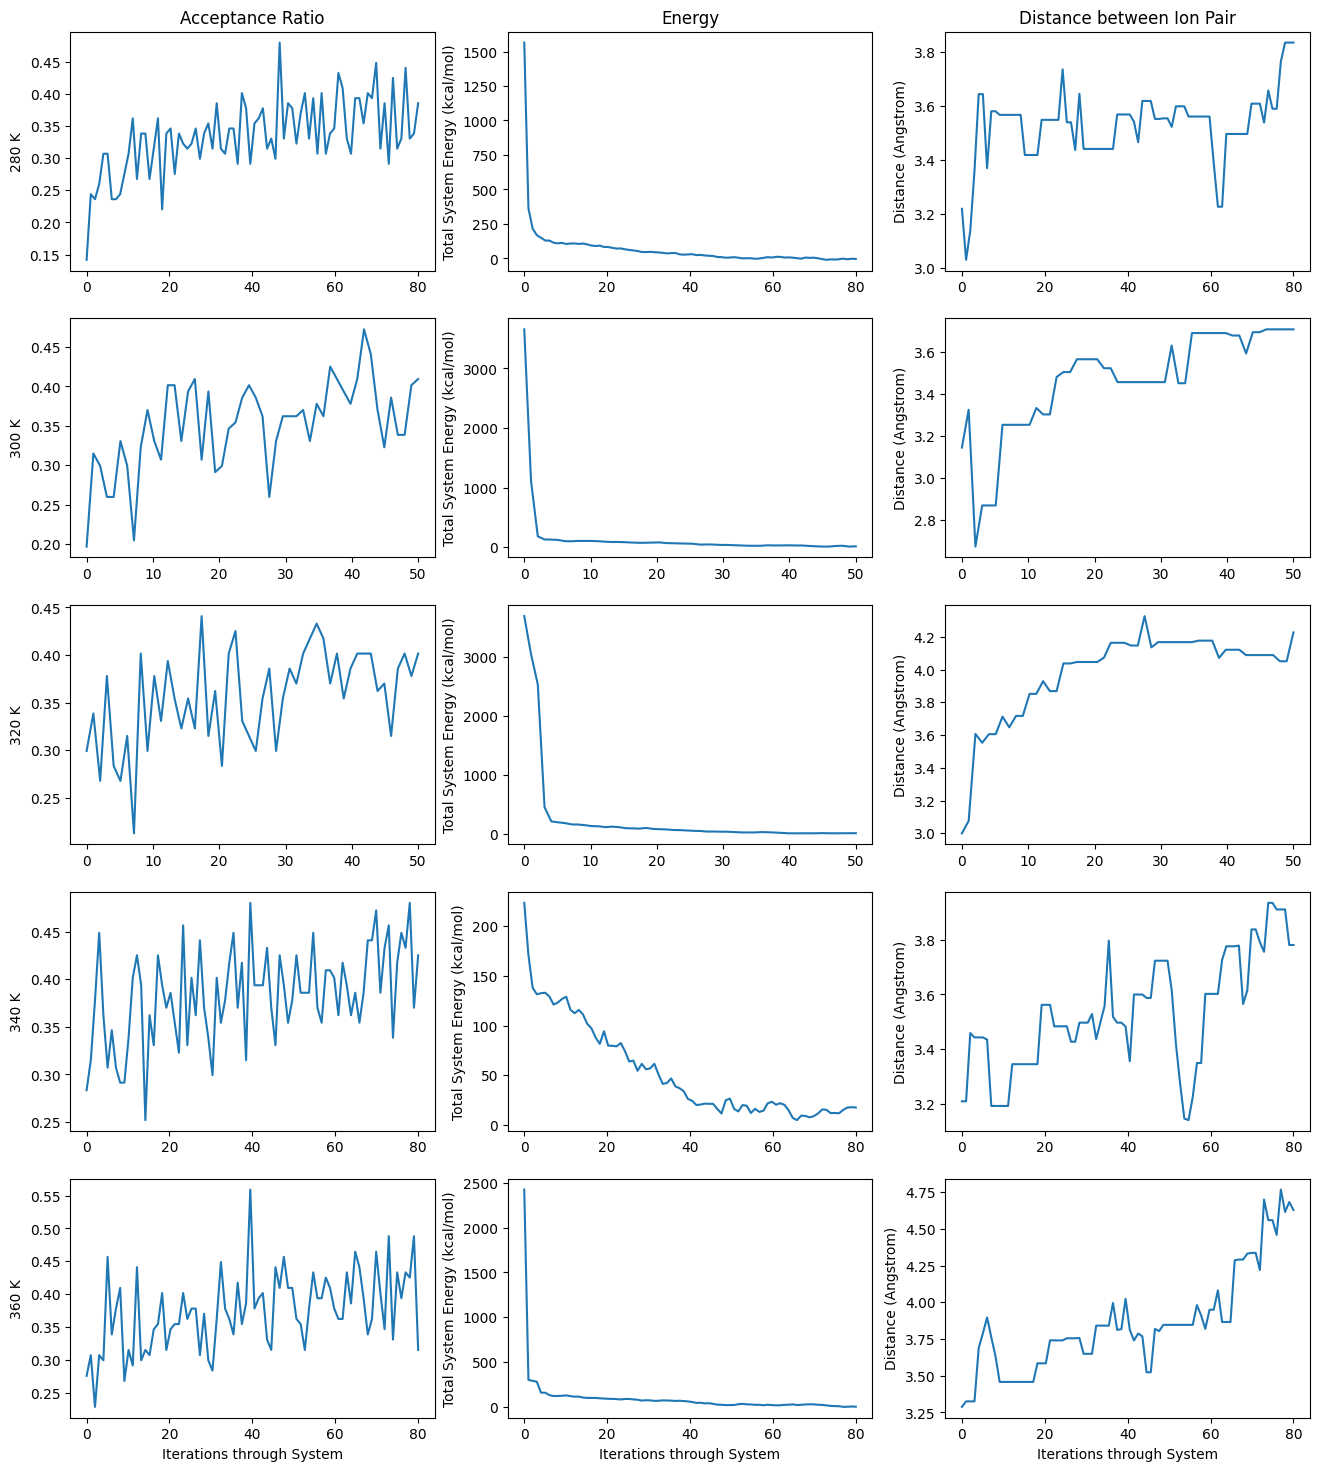

In [217]:
from matplotlib import pyplot as plt

energyDict = {}
distDict = {}
temps = ['280 K', '300 K', '320 K', '340 K', '360 K']
tempInts = [280 + i*20 for i in range(5)]
numbers = ['7', '5', '8', '9', '10']
fig, ax = plt.subplots(len(temps), 3)
fig.set_figheight(18)
fig.set_figwidth(16)
for i in range(len(numbers)):
    num = numbers[i]
    acceptances = readFile('MC_walk_acceptances_' + num)
    energy = readFile('MC_walk_energies_' + num)
    energyDict[tempInts[i]] = energy
    distances = readFile('MC_walk_ionic_distanace_' + num)
    distDict[tempInts[i]] = distances
    timerun = len(acceptances)
    t = numpy.linspace(0, timerun, timerun)
    ax[i, 0].plot(t, acceptances)
    ax[i, 1].plot(t, energy)
    ax[i, 2].plot(t, distances)
    ax[i, 0].set_ylabel(temps[i])
    ax[i, 1].set_ylabel('Total System Energy (kcal/mol)')
    ax[i, 2].set_ylabel('Distance (Angstrom)')
ax[0, 0].set_title('Acceptance Ratio')
ax[0, 1].set_title('Energy')
ax[0, 2].set_title('Distance between Ion Pair')
for i in range(3):
    ax[4, i].set_xlabel('Iterations through System')

for i in range(5):
    energyDict[tempInts[i]] = energyDict[tempInts[i]][-20:]
    distDict[tempInts[i]] = distDict[tempInts[i]][-20:]



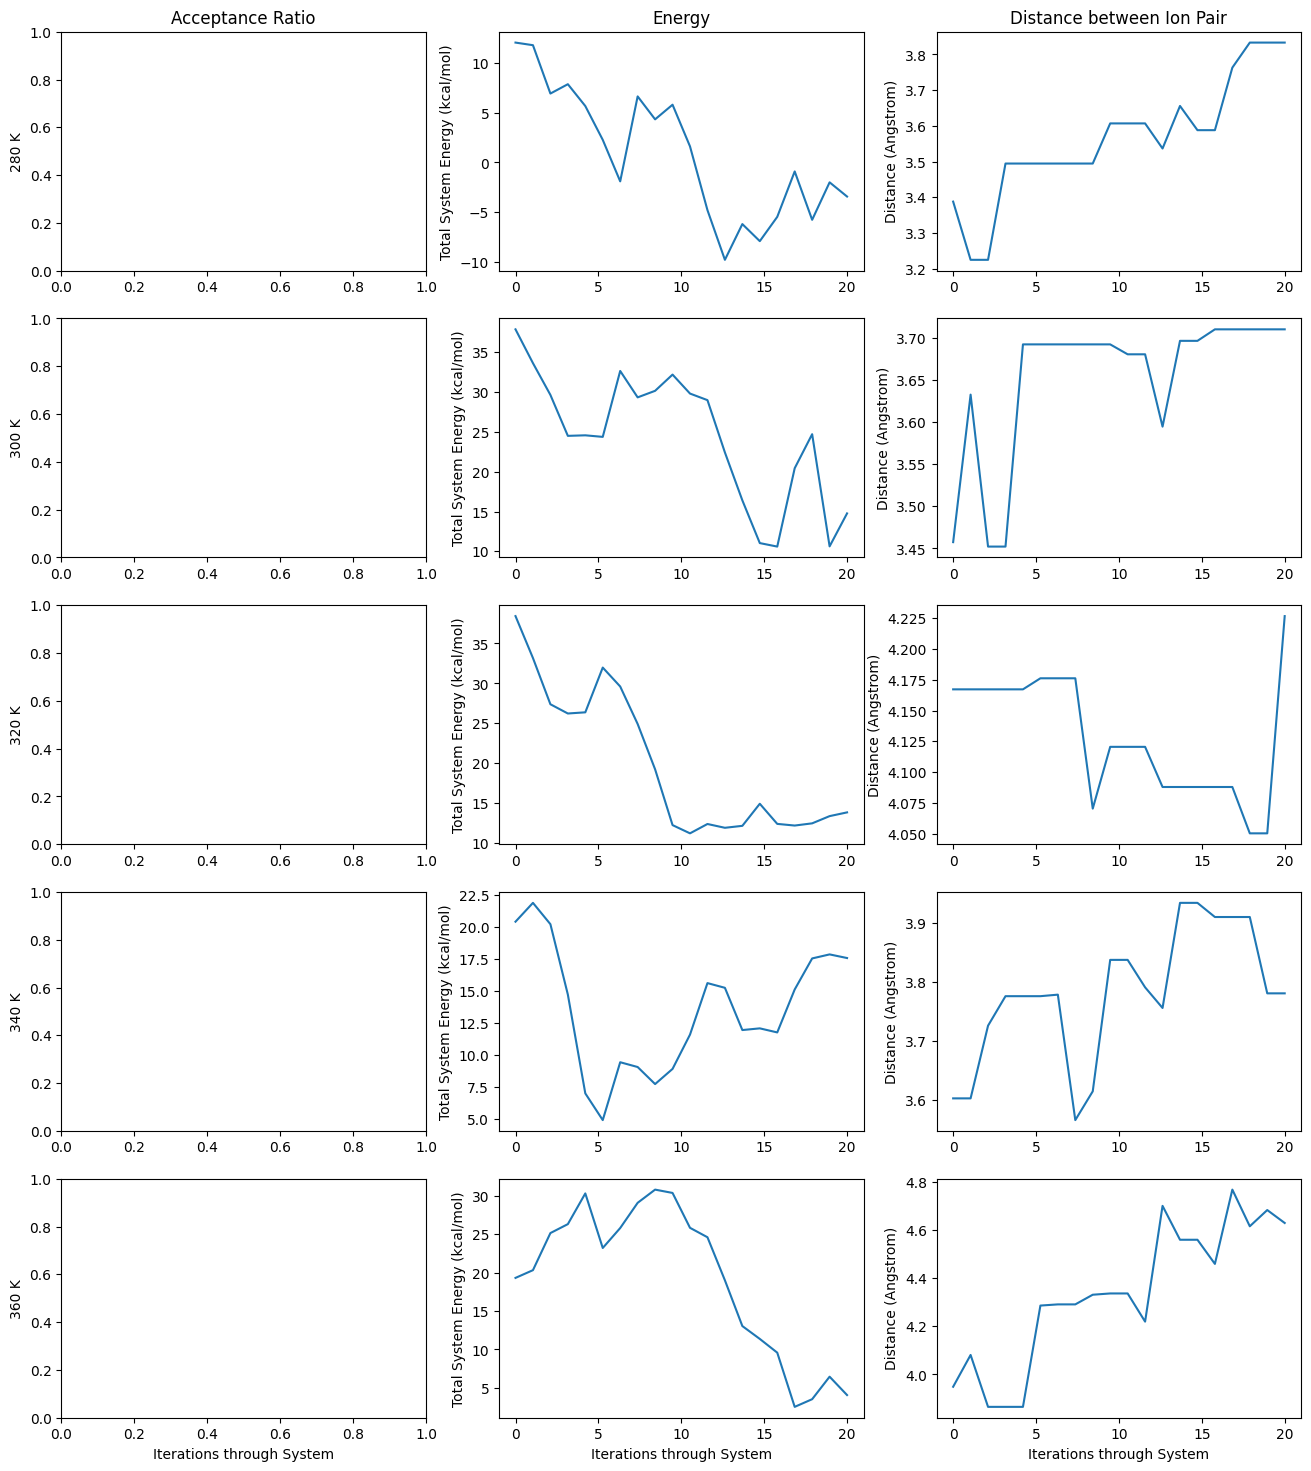

In [218]:
temps = ['280 K', '300 K', '320 K', '340 K', '360 K']
tempInts = [280 + i*20 for i in range(5)]
fig, ax = plt.subplots(len(temps), 3)
fig.set_figheight(18)
fig.set_figwidth(16)
for i in range(len(numbers)):
    energy = energyDict[tempInts[i]]
    t = len(energy)
    distances = distDict[tempInts[i]]
    timerun = len(energy)
    t = numpy.linspace(0, timerun, timerun)
    ax[i, 1].plot(t, energy)
    ax[i, 2].plot(t, distances)
    ax[i, 0].set_ylabel(temps[i])
    ax[i, 1].set_ylabel('Total System Energy (kcal/mol)')
    ax[i, 2].set_ylabel('Distance (Angstrom)')
ax[0, 0].set_title('Acceptance Ratio')
ax[0, 1].set_title('Energy')
ax[0, 2].set_title('Distance between Ion Pair')
for i in range(3):
    ax[4, i].set_xlabel('Iterations through System')
    
    #take the last twenty sec to process data

{280: 3.5630002637354443, 300: 3.6522871127861256, 320: 4.128204179470918, 340: 3.77957685161458, 360: 4.334279330385614}
[0.1748238327700875, 0.19476602410870258, -0.03900476612970838, 0.17757981050073823, 0.3851615383976763]
[3.388176430965357, 3.457521088677423, 4.167208945600627, 3.6019970411138416, 3.949117791987938]


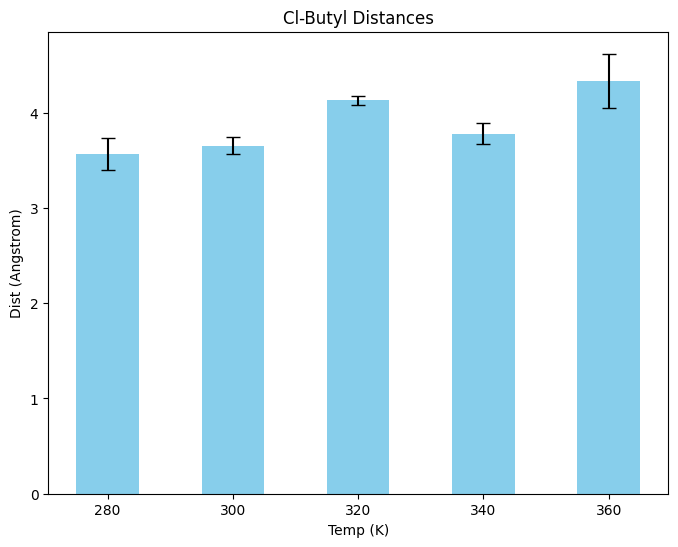

In [236]:
averages = {}
initials = []
errors = []
for temp in tempInts:
    averages[temp] = numpy.mean(distDict[temp])
    errors.append(numpy.std(distDict[temp]))
    initials.append(distDict[temp][0])
print(averages)
print([averages[tempInts[i]] - initials[i] for i in range(len(initials))])
print(initials)

import matplotlib.pyplot as plt

# Data for the bar graph
keys = list(averages.keys())
values = list(averages.values())

# Plotting the bar graph
plt.figure(figsize=(8, 6))
plt.bar(keys, values, width=10, yerr=errors, capsize=5, align='center', color='skyblue')

# Adding labels and title
plt.xlabel("Temp (K)")
plt.ylabel("Dist (Angstrom)")
plt.title("Cl-Butyl Distances")
plt.xticks(keys)

# Display the graph
plt.show()



Text(0.5, 1.0, 'Energy as a Function of Distance')

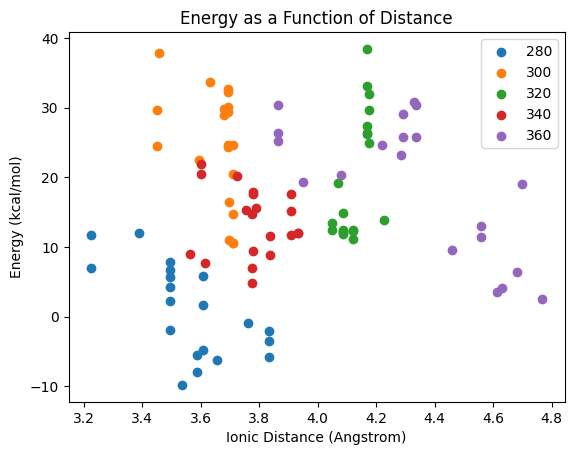

In [231]:
for temp in tempInts:
    plt.scatter(distDict[temp], energyDict[temp], label = str(temp))
plt.legend()
plt.ylabel('Energy (kcal/mol)')
plt.xlabel('Ionic Distance (Angstrom)')
plt.title("Energy as a Function of Distance")

Text(0, 0.5, 'Distance \n Between Ions')

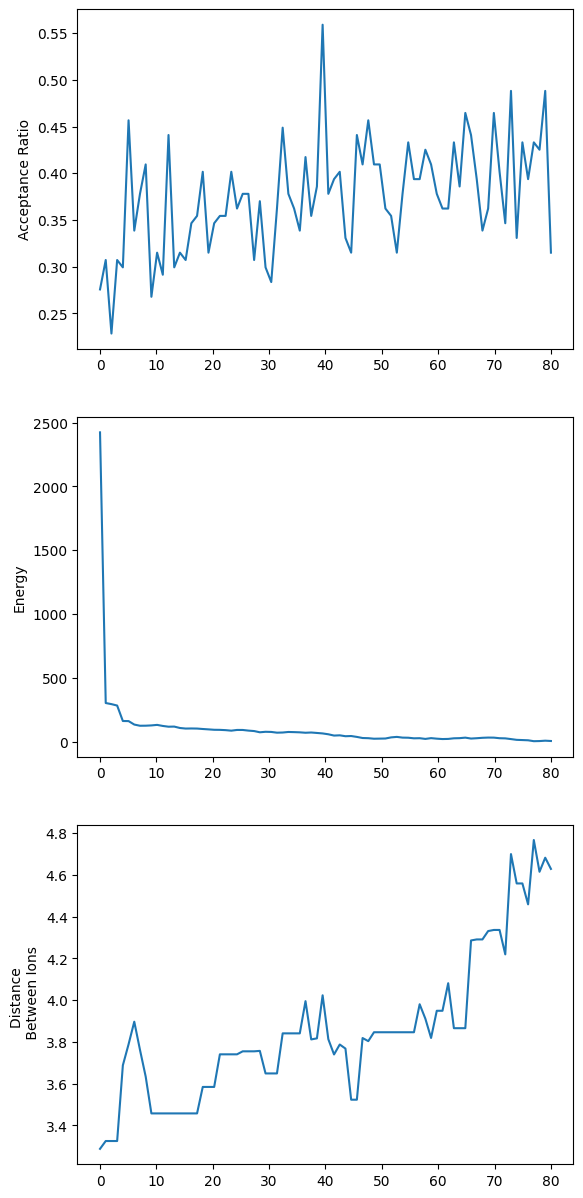

In [197]:
from matplotlib import pyplot as plt

t = numpy.linspace(0, 80, 80)
acceptances = readFile('MC_walk_acceptances_10')
energy = readFile('MC_walk_energies_10')
distances = readFile('MC_walk_ionic_distanace_10')
fig, ax = plt.subplots(3, 1)
fig.set_figheight(15)
ax[0].plot(t, acceptances)
ax[0].set_ylabel('Acceptance Ratio')
ax[1].plot(t, energy)
ax[1].set_ylabel("Energy")
ax[2].plot(t, distances)
ax[2].set_ylabel('Distance \n Between Ions')

Text(0, 0.5, 'Distance \n Between Ions')

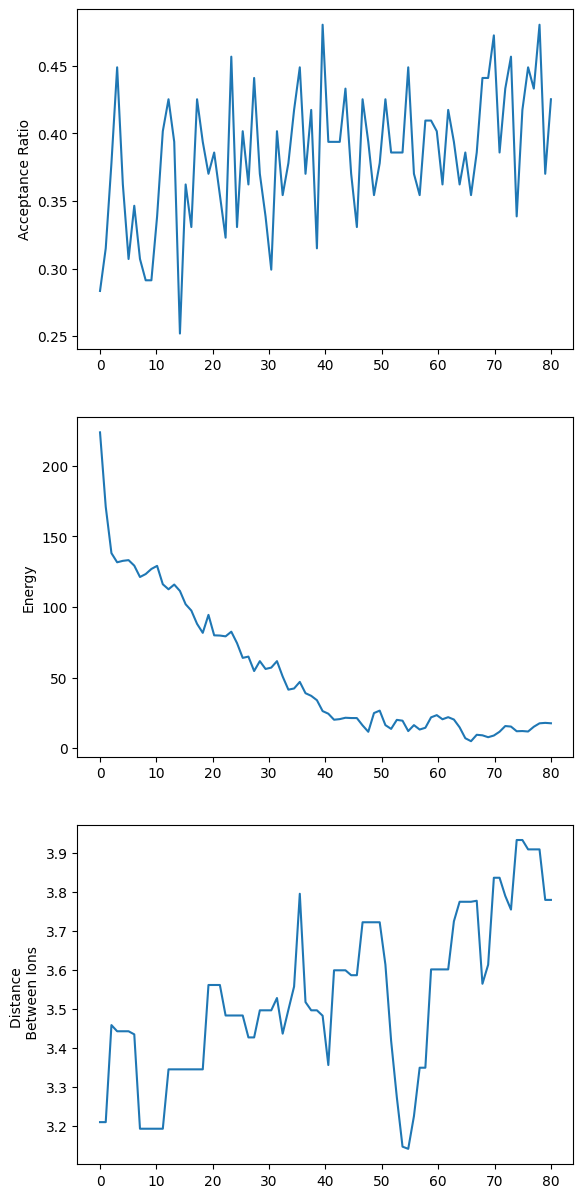

In [194]:
from matplotlib import pyplot as plt

t = numpy.linspace(0, 80, 80)
acceptances = readFile('MC_walk_acceptances_9')
energy = readFile('MC_walk_energies_9')
distances = readFile('MC_walk_ionic_distanace_9')
fig, ax = plt.subplots(3, 1)
fig.set_figheight(15)
ax[0].plot(t, acceptances)
ax[0].set_ylabel('Acceptance Ratio')
ax[1].plot(t, energy)
ax[1].set_ylabel("Energy")
ax[2].plot(t, distances)
ax[2].set_ylabel('Distance \n Between Ions')

Text(0, 0.5, 'Distance \n Between Ions')

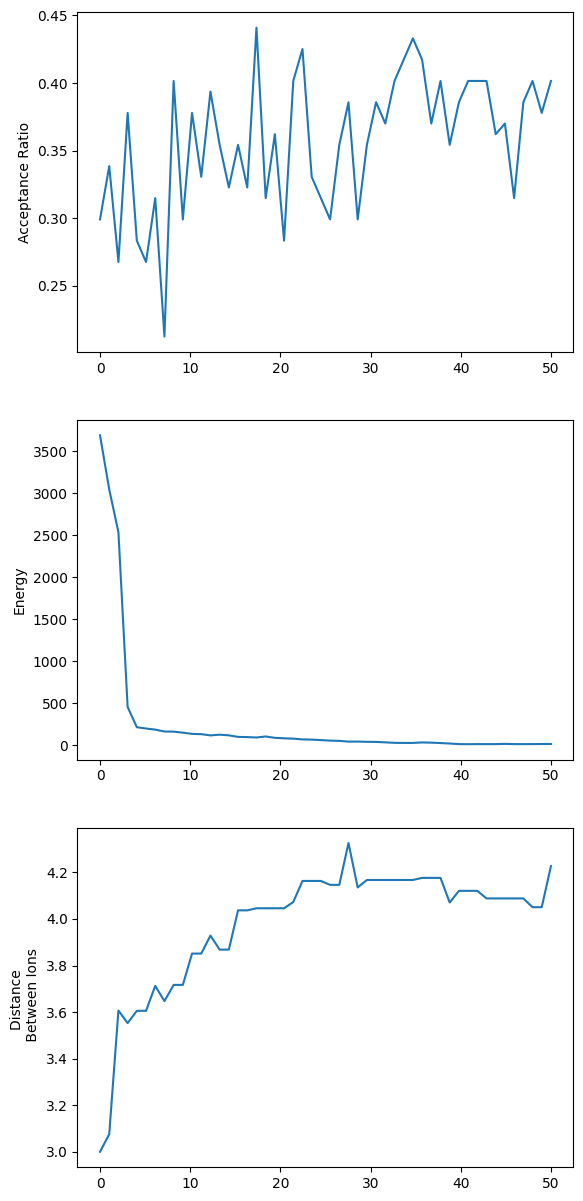

In [189]:
from matplotlib import pyplot as plt

t = numpy.linspace(0, 50, 50)
acceptances = readFile('MC_walk_acceptances_8')
energy = readFile('MC_walk_energies_8')
distances = readFile('MC_walk_ionic_distanace_8')
fig, ax = plt.subplots(3, 1)
fig.set_figheight(15)
ax[0].plot(t, acceptances)
ax[0].set_ylabel('Acceptance Ratio')
ax[1].plot(t, energy)
ax[1].set_ylabel("Energy")
ax[2].plot(t, distances)
ax[2].set_ylabel('Distance \n Between Ions')

Text(0, 0.5, 'Distance \n Between Ions')

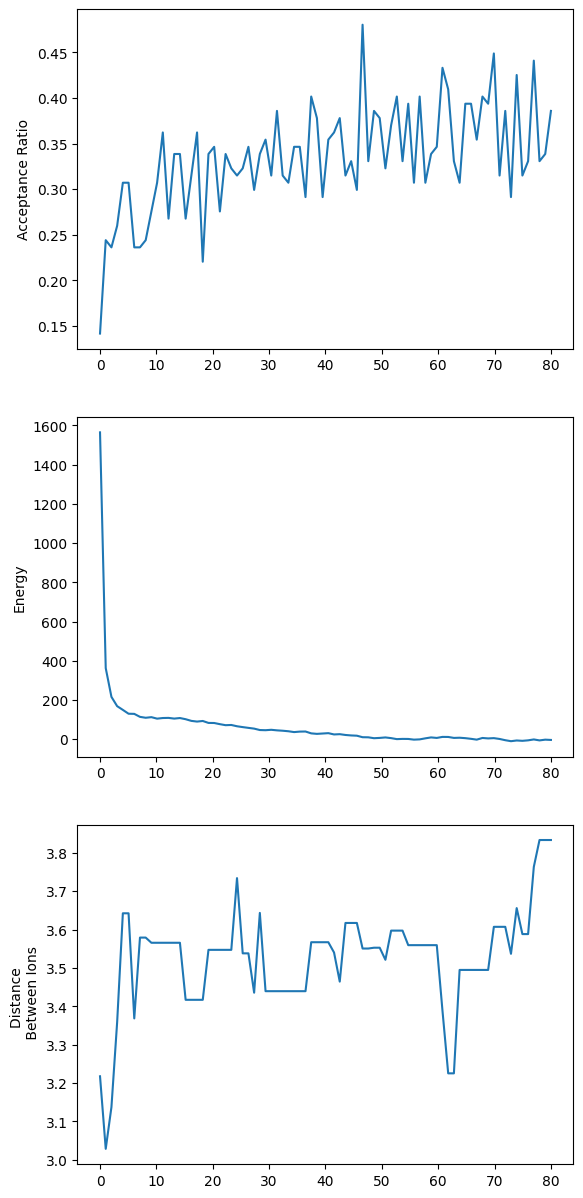

In [186]:
from matplotlib import pyplot as plt

t = numpy.linspace(0, 80, 80)
acceptances = readFile('MC_walk_acceptances_7')
energy = readFile('MC_walk_energies_7')
distances = readFile('MC_walk_ionic_distanace_7')
fig, ax = plt.subplots(3, 1)
fig.set_figheight(15)
ax[0].plot(t, acceptances)
ax[0].set_ylabel('Acceptance Ratio')
ax[1].plot(t, energy)
ax[1].set_ylabel("Energy")
ax[2].plot(t, distances)
ax[2].set_ylabel('Distance \n Between Ions')

Text(0, 0.5, 'Distance \n Between Ions')

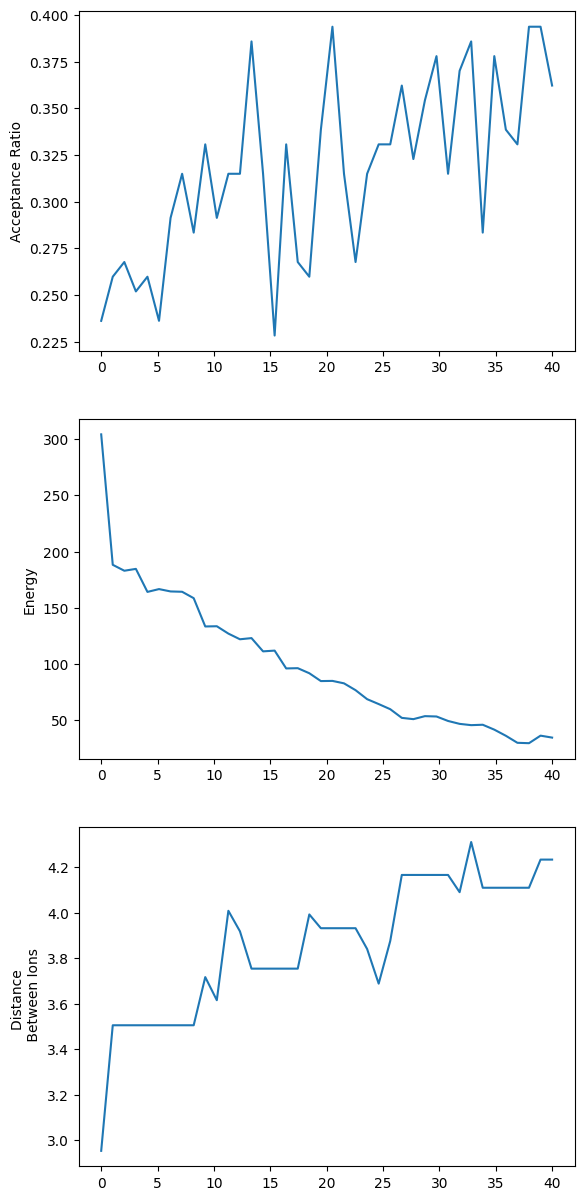

In [182]:
from matplotlib import pyplot as plt

t = numpy.linspace(0, 40, 40)
acceptances = readFile('MC_walk_acceptances_6')
energy = readFile('MC_walk_energies_6')
distances = readFile('MC_walk_ionic_distanace_6')
fig, ax = plt.subplots(3, 1)
fig.set_figheight(15)
ax[0].plot(t, acceptances)
ax[0].set_ylabel('Acceptance Ratio')
ax[1].plot(t, energy)
ax[1].set_ylabel("Energy")
ax[2].plot(t, distances)
ax[2].set_ylabel('Distance \n Between Ions')

Text(0, 0.5, 'Distance \n Between Ions')

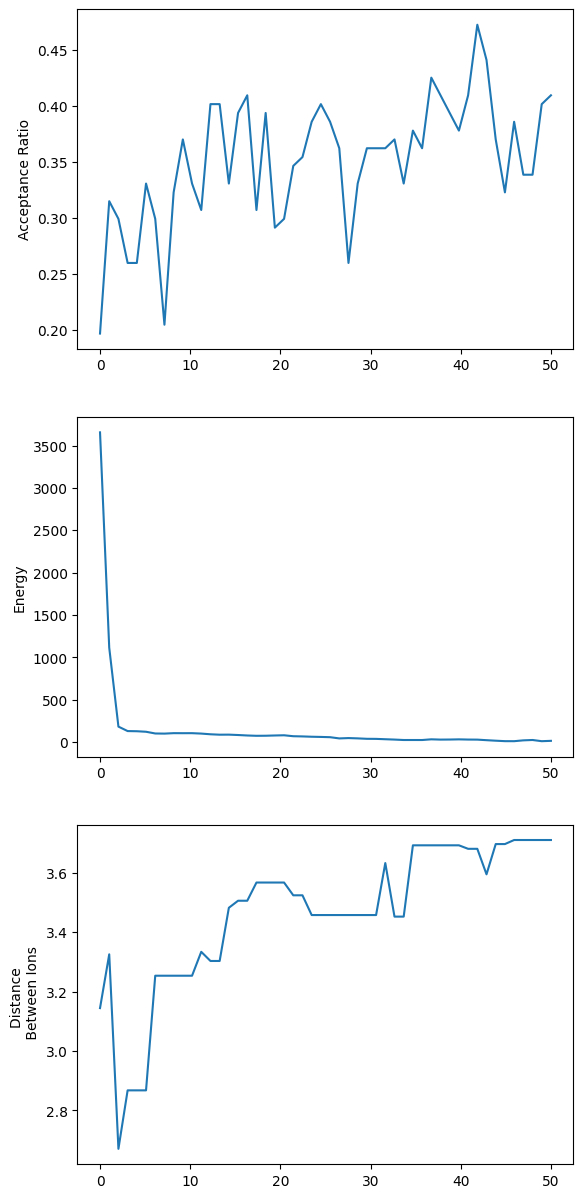

In [179]:
from matplotlib import pyplot as plt

t = numpy.linspace(0, 50, 50)
acceptances = readFile('MC_walk_acceptances_5')
energy = readFile('MC_walk_energies_5')
distances = readFile('MC_walk_ionic_distanace_5')
fig, ax = plt.subplots(3, 1)
fig.set_figheight(15)
ax[0].plot(t, acceptances)
ax[0].set_ylabel('Acceptance Ratio')
ax[1].plot(t, energy)
ax[1].set_ylabel("Energy")
ax[2].plot(t, distances)
ax[2].set_ylabel('Distance \n Between Ions')

In [36]:
butyl = MC1.molecules[MC1.cat].pos     
chl = MC1.molecules[MC1.an].pos    
print(butyl)
print(chl)
print(numpy.linalg.norm(butyl-chl))

[ 0.35793971 -2.64481482 -2.83884818]
[ 0.37878631 -0.06580448 -0.60501025]
3.412002462276482


Text(0, 0.5, 'Distance \n Between Ions')

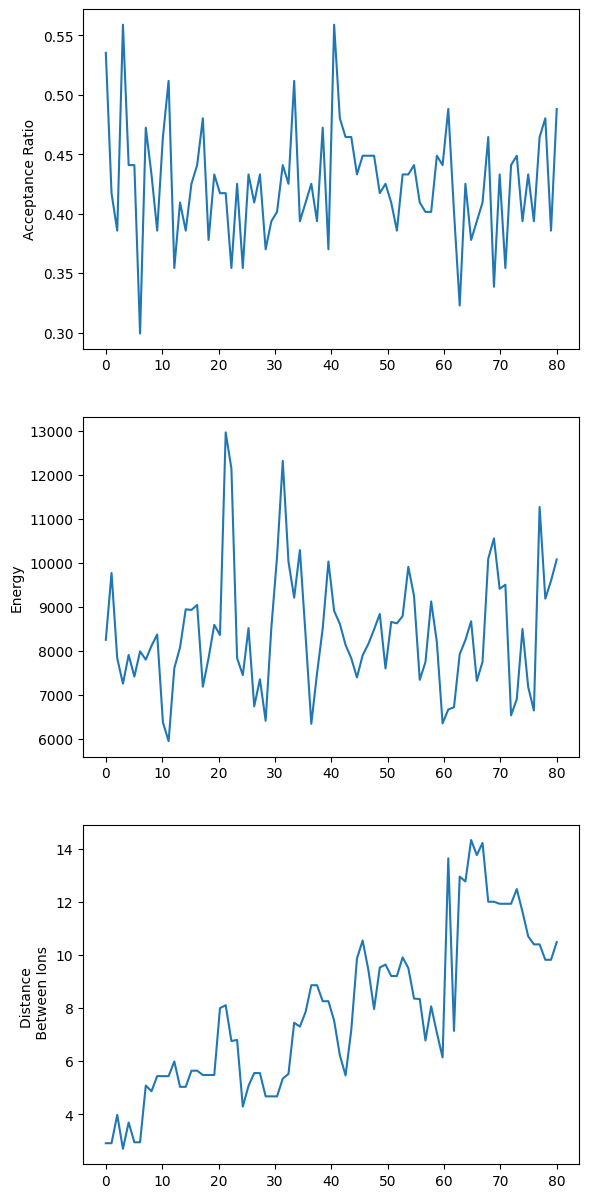

In [135]:



t = numpy.linspace(0, 80, 80)
acceptances = readFile('MC_walk_acceptances_3')
energy = readFile('MC_walk_energies_3')
distances = readFile('MC_walk_ionic_distanace_3')
fig, ax = plt.subplots(3, 1)
fig.set_figheight(15)
ax[0].plot(t, acceptances)
ax[0].set_ylabel('Acceptance Ratio')
ax[1].plot(t, energy)
ax[1].set_ylabel("Energy")
ax[2].plot(t, distances)
ax[2].set_ylabel('Distance \n Between Ions')

Text(0, 0.5, 'Distance \n Between Ions')

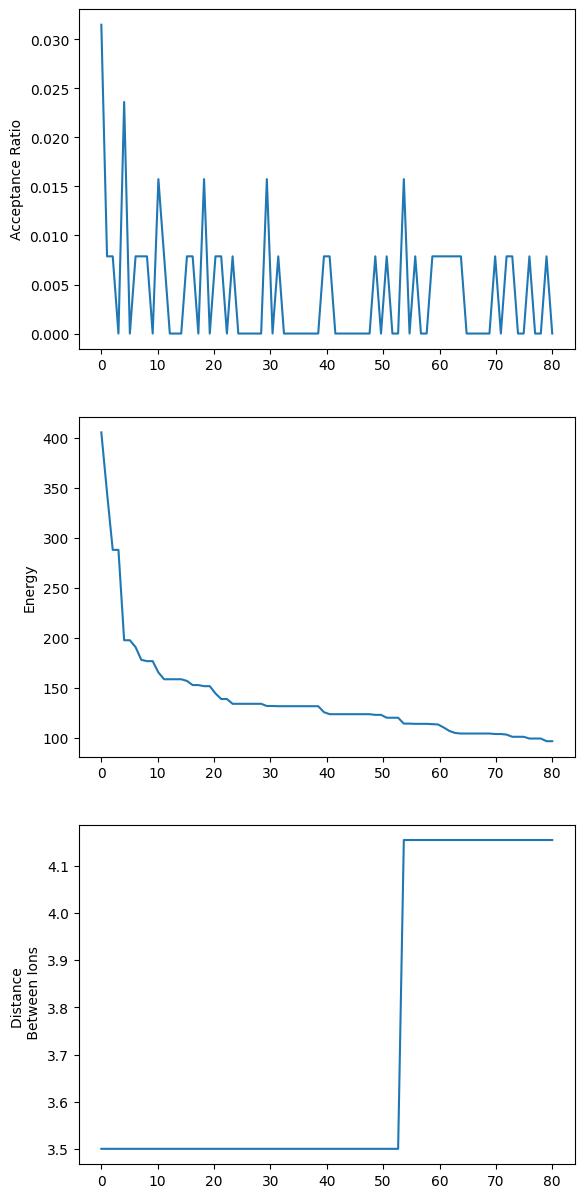

In [138]:
t = numpy.linspace(0, 80, 80)
acceptances = readFile('MC_walk_acceptances_4')
energy = readFile('MC_walk_energies_4')
distances = readFile('MC_walk_ionic_distanace_4')
fig, ax = plt.subplots(3, 1)
fig.set_figheight(15)
ax[0].plot(t, acceptances)
ax[0].set_ylabel('Acceptance Ratio')
ax[1].plot(t, energy)
ax[1].set_ylabel("Energy")
ax[2].plot(t, distances)
ax[2].set_ylabel('Distance \n Between Ions')

In [71]:
#tov gotta test this system
o = interactSite('O', numpy.array([0.0, 0.0, 0.0]))
h1 = interactSite('H', numpy.array([-0.75695, 0, -0.58588]))
h2 = interactSite('H', numpy.array([0.75695, 0, -0.58588]))
M = interactSite('M', numpy.array([0, 0, 0.15]))
water = molecule('water', numpy.array([0, 0, 0.4]), [o, h1, h2, M])
water.rotateMolZ()
print(numpy.linalg.norm(h1.relPos+ h2.relPos))
print(numpy.linalg.norm(h1.relPos-h2.relPos))
print(numpy.linalg.norm(numpy.cross(h1.relPos, h2.relPos)))


1.17176
1.5139
0.8869637319999999


In [44]:
def unit_vector(vector):
    """ Returns the unit vector of the vector.  """
    return vector / numpy.linalg.norm(vector)

def angle_between(v1, v2):
    """ Returns the angle in radians between vectors 'v1' and 'v2'::

            >>> angle_between((1, 0, 0), (0, 1, 0))
            1.5707963267948966
            >>> angle_between((1, 0, 0), (1, 0, 0))
            0.0
            >>> angle_between((1, 0, 0), (-1, 0, 0))
            3.141592653589793
    """
    v1_u = unit_vector(v1)
    v2_u = unit_vector(v2)
    return numpy.arccos(numpy.clip(numpy.dot(v1_u, v2_u), -1.0, 1.0))

[0.  0.  0.4]
[-0.64207495  0.70943562  0.37412452]
[-0.34644717 -0.61373152  1.0477165 ]
1.8242214773375076
0.9571983477315458
0.9571983477315457


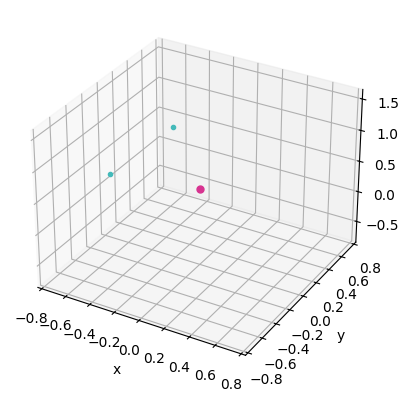

In [78]:
import matplotlib.pyplot as plt
water.rotateMolY()
water.rotateMolZ()
water.rotateMolY()
ax = plt.figure().add_subplot(projection='3d')
p = water.pos
ax.plot(p[0], p[1], p[2], '.', color = '#d73390', ms = 10)
hyd1rel = water.interactionSites[1].relPos
hyd1 = p + hyd1rel
hyd2rel = water.interactionSites[2].relPos
ax.plot(hyd1[0], hyd1[1], hyd1[2], '.', color = '#44baba')
ax.set_xlabel('x')
ax.set_ylabel('y')
ax.set_xlim([-0.8, 0.8])
ax.set_ylim([-0.8, 0.8])
ax.set_zlim([-0.8, 1.6])
hyd2 = p + hyd2rel
ax.plot(hyd2[0], hyd2[1], hyd2[2], '.', color = '#44baba')
print(p)
print(hyd1)
print(hyd2)
print(angle_between(hyd1rel, hyd2rel))
print(numpy.linalg.norm(hyd1rel))
print(numpy.linalg.norm(hyd2rel))

In [79]:
C = interactSite('C', numpy.array([0, 0, 0]))
Me1 = interactSite('methyl', numpy.array([-1.277387, 0.0, -0.73750]))
Me2 = interactSite('methyl', numpy.array([1.277387, 0.0, -0.73750]))
Me3 = interactSite('methyl', numpy.array([0, 0, 1.475]))
tbutyl = molecule('tbutyl', numpy.array([0, 0, 0.5]), [C, Me1, Me2, Me3])
print(numpy.linalg.norm(Me1.relPos+ Me2.relPos))
print(numpy.linalg.norm(Me1.relPos-Me2.relPos))
print(numpy.linalg.norm(numpy.cross(Me1.relPos, Me2.relPos)))

1.475
2.554774
1.8841458250000003


[0.  0.  0.5]
[-0.72996419  0.0961241  -0.77809868]
[1.44881835 0.27312343 0.54419027]
2.094394783354432
2.0943952619125787
2.0943952619125756
1.474999592464013
1.4749995924640107
1.4749999999999994


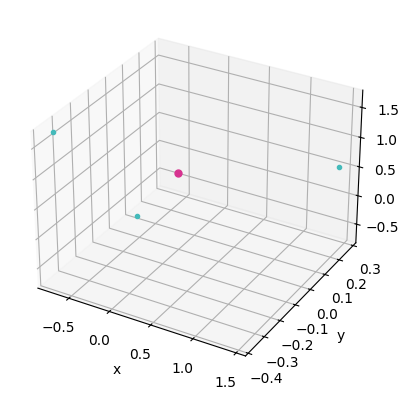

In [100]:
tbutyl.rotateMolY()
tbutyl.rotateMolZ()
ax = plt.figure().add_subplot(projection='3d')
p = tbutyl.pos
ax.plot(p[0], p[1], p[2], '.', color = '#d73390', ms = 10)
hyd1rel = tbutyl.interactionSites[1].relPos
hyd1 = p + hyd1rel
hyd2rel = tbutyl.interactionSites[2].relPos
meth3 = tbutyl.interactionSites[3].relPos
ax.plot(hyd1[0], hyd1[1], hyd1[2], '.', color = '#44baba')
ax.set_xlabel('x')
ax.set_ylabel('y')
#ax.set_xlim([-0.8, 0.8])
#ax.set_ylim([-0.8, 0.8])
#ax.set_zlim([-0.8, 1.6])
hyd2 = p + hyd2rel
methyl3 = p + meth3
ax.plot(hyd2[0], hyd2[1], hyd2[2], '.', color = '#44baba')
ax.plot(methyl3[0], methyl3[1], methyl3[2], '.', color = '#44baba')
print(p)
print(hyd1)
print(hyd2)
print(angle_between(hyd1rel, hyd2rel))
print(angle_between(hyd1rel, meth3))
print(angle_between(meth3, hyd2rel))
print(numpy.linalg.norm(hyd1rel))
print(numpy.linalg.norm(hyd2rel))
print(numpy.linalg.norm(meth3))